## Level 5 Data Engineer
## Module 3 Topic 9


# Pip Installs

In [1]:
!pip install pandasql
!pip install sqlalchemy
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 1.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0


In [2]:
# you might want to try this, but it seems recent changes are holding it back!
!pip install sweetviz

# Library Imports

In [3]:
import pandas as pd
from pandasql import sqldf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sweetviz as sv
import os
import seaborn as sns
import warnings
import logging

warnings.filterwarnings('ignore')

In [4]:
# font size globally defined
font = {'family' : 'normal',
'weight' : 'bold',
'size' : 14}

matplotlib.rc('font', **font)

In [5]:
import kagglehub

# Download latest version
data_path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", data_path)

Path to dataset files: /kaggle/input/default-of-credit-card-clients-dataset


In [6]:
os.listdir(data_path)

['UCI_Credit_Card.csv']

In [7]:
# load our data
data = pd.read_csv(os.path.join(data_path, 'UCI_Credit_Card.csv'))
data = data[['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
             'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
             'default.payment.next.month']]
data.rename(columns={
    'ID':'CLIENT_ID',
    'default.payment.next.month':'DEFAULT'}, inplace=True)
data.head()

,CLIENT_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,0


Data dictionary

- **CLIENT_ID**: Unique identifier for each client.
- **LIMIT_BAL**: The total credit amount (in pound sterling) granted to the client, including both individual and supplementary credit.
- **SEX**: (1 = male, 2 = female).
- **EDUCATION**: Client's highest level of education (1 = university, 2 = college, 3 = apprenticeship, 4 = unknown, 5 = GCSE, 6 = unknown).
- **MARRIAGE**: Client's marital status (1 = married, 2 = single, 3 = other).
- **AGE**: Client's age in years.
- **PAY_0**: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- **PAY_2**: Repayment status in August 2005, with the same scale as PAY_0.
- **PAY_3**: Repayment status in July 2005, with the same scale as PAY_0.
- **PAY_4**: Repayment status in June 2005, with the same scale as PAY_0.
- **PAY_5**: Repayment status in May 2005, with the same scale as PAY_0.
- **PAY_6**: Repayment status in April 2005, with the same scale as PAY_0.
- **Default**: Credit card default states (0=No, 1=Yes).

In [8]:
for col in data.columns[2:-1]:
    data[col] = data[col].astype(str)
data.dtypes

,0
CLIENT_ID,int64
LIMIT_BAL,float64
SEX,object
EDUCATION,object
MARRIAGE,object
AGE,object
PAY_0,object
PAY_2,object
PAY_3,object
PAY_4,object


DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


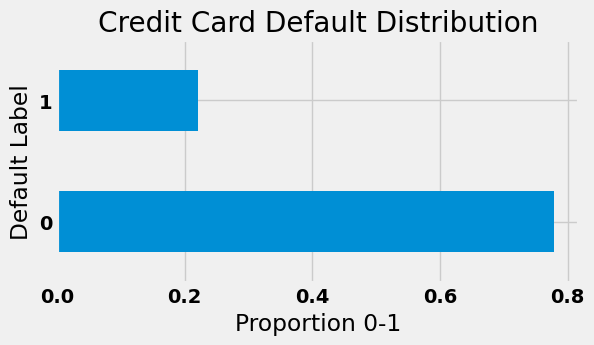

In [9]:
# value counts of default
plt.style.use('fivethirtyeight')
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.CRITICAL)

fig, ax = plt.subplots(figsize=(6,3))

data['DEFAULT'].value_counts(normalize=True).plot(kind='barh', ax=ax)
print(data['DEFAULT'].value_counts(normalize=True) *100)

ax.set(xlabel='Proportion 0-1', ylabel='Default Label', title='Credit Card Default Distribution');

# Data Profiling

In [10]:
# Report = sv.analyze(data, target_feat='DEFAULT')
# Report.show_notebook()

In [11]:
# Report.show_html('EDA.html')

# Train-Test Split

In [12]:
# cleaning up the data
lower_names = []

for column_name in data.columns:
    lower_names.append(column_name.lower())

data.columns = lower_names

In [13]:
data.columns = [col.lower() for col in data.columns]

In [14]:
data.columns

Index(['client_id', 'limit_bal', 'sex', 'education', 'marriage', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'default'],
      dtype='object')

In [15]:
# what is our distribution for the target variable in the original data?

data['default'].value_counts(normalize=True) * 100

,proportion
default,
0,77.88
1,22.12


In [16]:
# split the data into train - test set
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(data, test_size=0.3,
                                     random_state=1234,
                                     stratify=data['default'])

print(df_train['default'].value_counts(normalize=True))
print(df_test['default'].value_counts(normalize=True))

default
0    0.77881
1    0.22119
Name: proportion, dtype: float64
default
0    0.778778
1    0.221222
Name: proportion, dtype: float64


In [17]:
# what did we do?
print(data.shape)
print(df_train.shape)
print(df_test.shape)

(30000, 13)
(21000, 13)
(9000, 13)


# Exploratory Data Analysis (EDA)

In [18]:
df_train['default'].mean()

np.float64(0.2211904761904762)

# Feature Engineering / Extraction

It is the formal process of taking raw data and creating new columns and measures by combining existing columns or applying formulas on them.



In [19]:
# helper function to add together positive delay values
def sum_positive(series):
    filter_condition = series > 0
    return series[filter_condition].sum()

In [20]:
data.columns

Index(['client_id', 'limit_bal', 'sex', 'education', 'marriage', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'default'],
      dtype='object')

In [22]:
data.dtypes

,0
client_id,int64
limit_bal,float64
sex,object
education,object
marriage,object
age,object
pay_0,object
pay_2,object
pay_3,object
pay_4,object


In [24]:
# calculate features for df train

df_train['avg_delay'] = (df_train[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']].astype(int)
                         .apply(lambda x: x[x > 0].mean(), axis=1))


df_train['avg_delay'].fillna(0, inplace=True)

df_train.head()

,client_id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_delay
7187,7188,20000.0,1,2,2,25,1,2,2,2,2,0,0,1.80
4789,4790,20000.0,2,2,2,35,1,3,2,0,0,0,0,2.00
27298,27299,50000.0,1,1,2,32,0,0,2,3,2,2,1,2.25
28136,28137,50000.0,2,3,1,44,0,0,0,0,0,0,0,0.00
29616,29617,280000.0,1,3,1,45,-2,-2,-2,-2,-2,-2,0,0.00


In [23]:
# create extra information - df test
df_test['avg_delay'] = (df_test[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']].astype(int)
                         .apply(lambda x: x[x > 0].mean(), axis=1))

df_test['avg_delay'].fillna(0, inplace=True)

df_test.head()

,client_id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_delay
28909,28910,310000.0,2,2,2,34,0,0,0,0,0,0,0,0.000000
22232,22233,200000.0,2,3,2,32,0,0,0,0,0,0,0,0.000000
21390,21391,190000.0,1,3,1,67,2,2,2,2,0,0,0,2.000000
1081,1082,10000.0,1,2,1,32,1,2,2,2,2,2,0,1.833333
26967,26968,350000.0,1,1,2,32,0,0,0,0,0,0,0,0.000000


In [26]:
# total payment delay
df_train['total_delay'] = (df_train[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']].astype(int)
                         .apply(sum_positive, axis=1))

df_train.head()

,client_id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_delay,total_delay
7187,7188,20000.0,1,2,2,25,1,2,2,2,2,0,0,1.80,9
4789,4790,20000.0,2,2,2,35,1,3,2,0,0,0,0,2.00,6
27298,27299,50000.0,1,1,2,32,0,0,2,3,2,2,1,2.25,9
28136,28137,50000.0,2,3,1,44,0,0,0,0,0,0,0,0.00,0
29616,29617,280000.0,1,3,1,45,-2,-2,-2,-2,-2,-2,0,0.00,0


| Feature    | Value  | Description                                              |
|------------|--------|----------------------------------------------------------|
| CLIENT_ID  | 7188   | Unique identifier for the client                         |
| LIMIT_BAL  | 20000  | Total credit amount (in NT dollars)                      |
| SEX        | 1      | Gender (1 = male)                                        |
| EDUCATION  | 2      | Highest level of education (2 = university)              |
| MARRIAGE   | 2      | Marital status (2 = single)                              |
| AGE        | 25     | Age in years                                             |
| PAY_0      | 1      | Repayment status in September 2005 (1 month delayed)     |
| PAY_2      | 2      | Repayment status in August 2005 (2 months delayed)       |
| PAY_3      | 2      | Repayment status in July 2005 (2 months delayed)         |
| PAY_4      | 2      | Repayment status in June 2005 (2 months delayed)         |
| PAY_5      | 2      | Repayment status in May 2005 (2 months delayed)          |
| PAY_6      | 0      | Repayment status in April 2005 (revolving credit or no transactions) |
| DEFAULT    | 0      | Credit card default status (1 = Yes)                     |
| avg_delay  | 1.80   | Average delay in payments across all months              |
| total_delay| 9      | Total delay in payments across all months                |


In [27]:
# total delay with the test set
df_test['total_delay'] = (df_test[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']].astype(int)
                         .apply(sum_positive, axis=1))

df_test.head()

,client_id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_delay,total_delay
28909,28910,310000.0,2,2,2,34,0,0,0,0,0,0,0,0.000000,0
22232,22233,200000.0,2,3,2,32,0,0,0,0,0,0,0,0.000000,0
21390,21391,190000.0,1,3,1,67,2,2,2,2,0,0,0,2.000000,8
1081,1082,10000.0,1,2,1,32,1,2,2,2,2,2,0,1.833333,11
26967,26968,350000.0,1,1,2,32,0,0,0,0,0,0,0,0.000000,0


## Pandas Groupby Function

The Pandas `groupby` function is a powerful method used for grouping DataFrame rows based on the values of one or more columns. It enables you to perform various aggregation operations on the grouped data, such as computing the sum, mean, count, or other custom aggregation functions.

### Syntax

`DataFrame.groupby(by, axis, level, as_index, sort, group_keys, squeeze, observed)`

- `by`: The column(s) to group by. Can be a single column, a list of columns, or a dictionary mapping columns to group names.
- `axis`: The axis to group along, either 0 (default) for rows or 1 for columns.
- `sort`: If `True` (default), the group keys will be sorted. If `False`, the group keys will not be sorted, which may improve performance.
- `group_keys`: If `True` (default), the group keys will be included in the result. If `False`, the group keys will not be included.
- `observed`: If `True`, only show observed values for categorical groupers. If `False` (default), show all values.

### Basic Example

```python
import pandas as pd

# Sample DataFrame
data = {'Category': ['A', 'B', 'A', 'B', 'A', 'B'],
        'Value': [10, 20, 30, 40, 50, 60]}
df = pd.DataFrame(data)

# Group by Category
grouped = df.groupby('Category')

# Compute the sum of the Value column for each group
result = grouped['Value'].sum()


In [28]:
# hypothesis: customers who delay more often and over longer durations default more!
agg_df1 = df_train\
  .groupby('total_delay')\
  .agg(count=("total_delay", "size"),
       mean_target=("default", "mean")).reset_index()

agg_df1

,total_delay,count,mean_target
0,0,13944,0.117183
1,1,1141,0.250657
2,2,1981,0.327612
3,3,531,0.316384
4,4,702,0.421652
5,5,329,0.422492
6,6,438,0.550228
7,7,273,0.443223
8,8,353,0.651558
9,9,144,0.541667


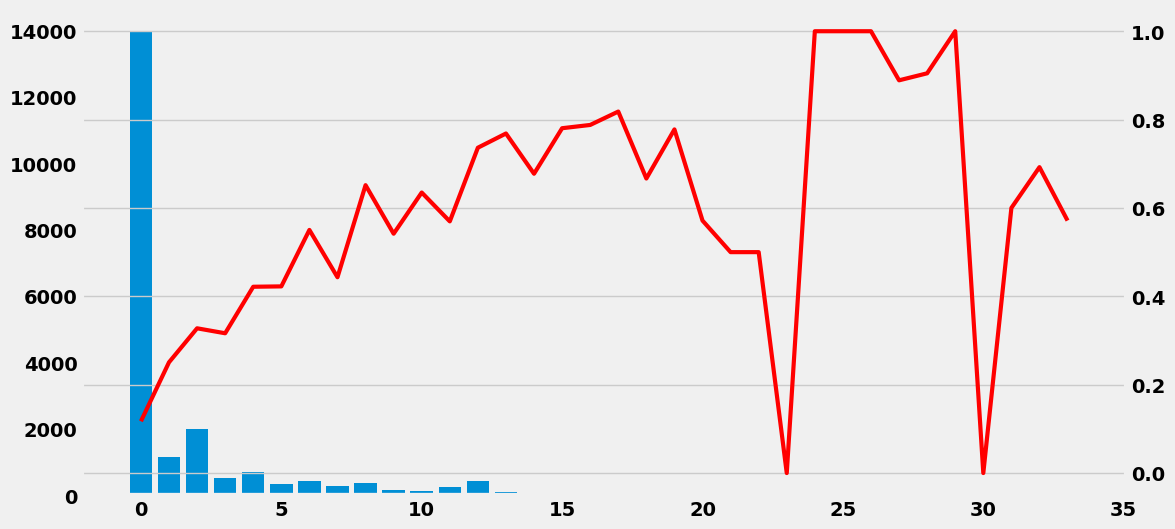

In [29]:
# visualise
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(12,6))

# create secondary y-axis
ax2 = ax.twinx()

ax.bar(list(agg_df1['total_delay']), list(agg_df1["count"]))
ax2.plot(list(agg_df1['mean_target']), color='r', linewidth=3)

ax.grid(False)

In [30]:
# average delay
agg_df2 = df_train\
  .groupby('avg_delay')\
  .agg(count=("avg_delay", "size"),
       mean_target=("default", "mean")).reset_index()

agg_df2.head()

,avg_delay,count,mean_target
0,0.000000,13944,0.117183
1,1.000000,1160,0.248276
2,1.250000,1,0.000000
3,1.500000,522,0.316092
4,1.666667,265,0.392453


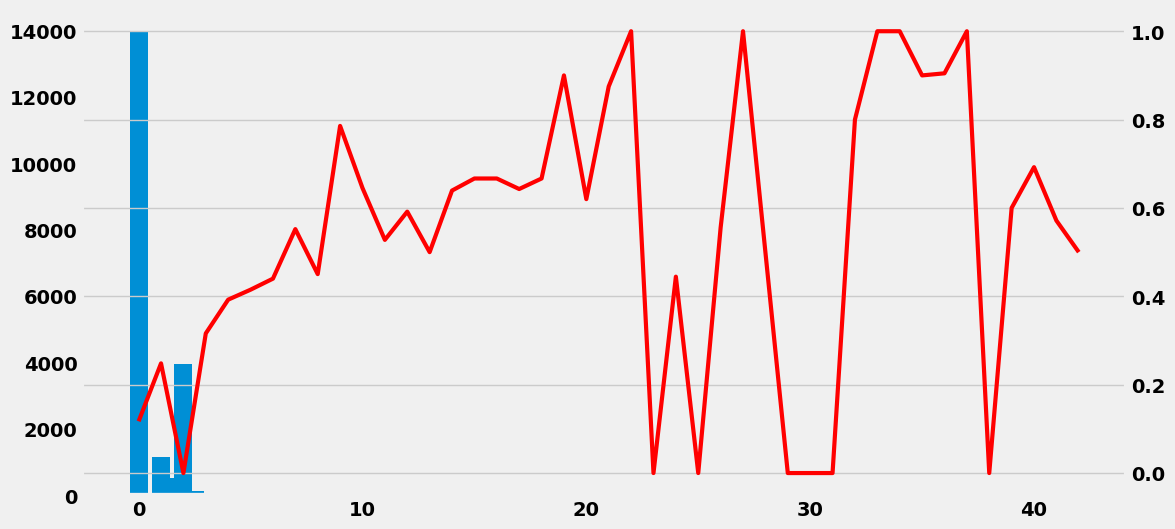

In [31]:
# visualise
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(12,6))

# create secondary y-axis
ax2 = ax.twinx()

ax.bar(list(agg_df2['avg_delay']), list(agg_df2["count"]))
ax2.plot(list(agg_df2['mean_target']), color='r', linewidth=3)

ax.grid(False)

# Feature Selection - What do we include in our model?

In [32]:
# what are the irrelevant columns?
df_train.columns

Index(['client_id', 'limit_bal', 'sex', 'education', 'marriage', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'default',
       'avg_delay', 'total_delay'],
      dtype='object')

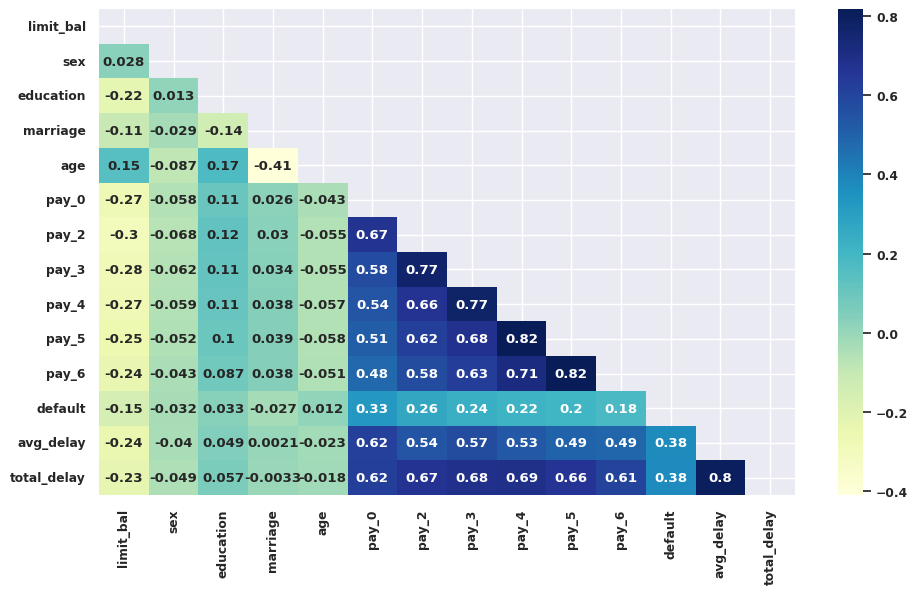

In [33]:
# let us look at a correlation matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)

correlation_matrix = df_train.drop('client_id', axis=1).corr()

fig, ax = plt.subplots(figsize=(10,6))

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

ax = sns.heatmap(correlation_matrix, mask=mask, ax=ax, cmap='YlGnBu', annot=True)

# Model Building - Predictive Analytics

Step 1) Drop all the irrelevant columns and split X_train, X_test

Step 2) Select the right model and import it and use it to train

Step 3) We train on the training sets & test on the X_test (generating y_pred - basically running the model)

Step 4) We evaluate the performance of our y_pred against the true values of y_test (i.e., generate the accuracy and loss metrices)

Step 5) Model diagnostics - creating reports on the model performance

Step 6) Conclusion model is not good enough and we need to fine-tune / or model is good enough and we can publish!

In [34]:
# what is the right model to pick?
df_train['default'].unique()

array([0, 1])

**Our Prediction Problem is a Classification Task! Binary Classification**

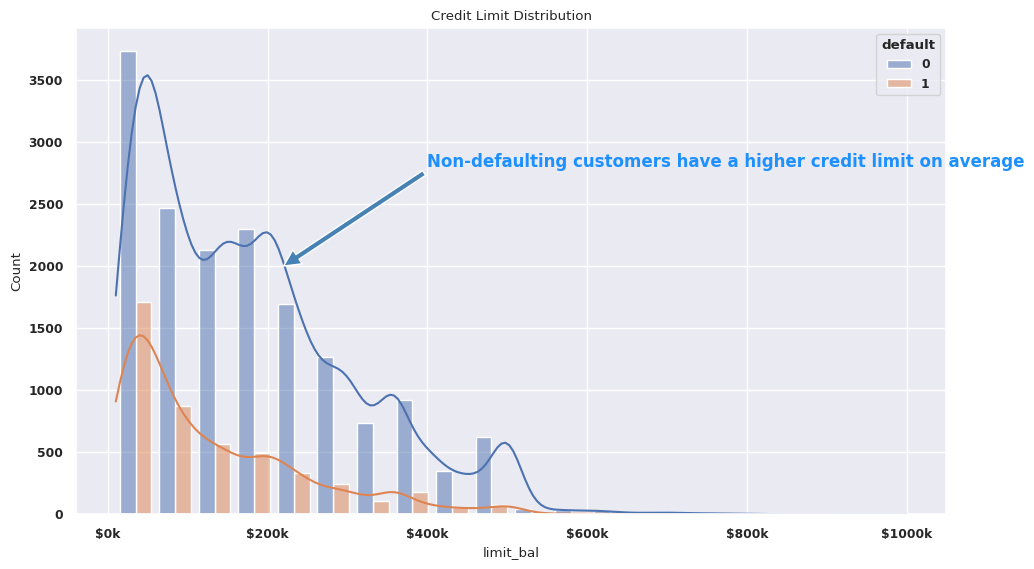

In [35]:
# what is the effect of limit_balance
# are customer with high limit balance less likely to default?

# Distribution of LIMIT_BAL
import matplotlib.ticker as mticker
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_train, x='limit_bal', kde=True, hue="default",
             bins=20, multiple="dodge", ax=ax, shrink=0.8)

# Format x-axis with dollar sign and "k" for thousands
formatter = mticker.FuncFormatter(lambda x, pos: f"${int(x/1000)}k")
ax.xaxis.set_major_formatter(formatter)

# Set the title
ax.set_title('Credit Limit Distribution')

# Add arrow annotation
arrow_props = dict(facecolor='steelblue')
ax.annotate('Non-defaulting customers have a higher credit limit on average',
             xy=(220000, 2000), xytext=(400000, 2800),
             fontsize=12, color='dodgerblue', arrowprops=arrow_props)

plt.show()

In [36]:
print(df_train.columns)

Index(['client_id', 'limit_bal', 'sex', 'education', 'marriage', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'default',
       'avg_delay', 'total_delay'],
      dtype='object')


In [37]:
# drop the irrelevant columns
# marriage, education, client_id, age, age_group
cols_to_drop = ['client_id', 'sex', 'education', 'marriage', 'age']

df_train.drop(cols_to_drop, axis=1, inplace=True)
df_test.drop(cols_to_drop, axis=1, inplace=True)

In [38]:
df_train.head(20)

,limit_bal,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,default,avg_delay,total_delay
7187,20000.0,1,2,2,2,2,0,0,1.80,9
4789,20000.0,1,3,2,0,0,0,0,2.00,6
27298,50000.0,0,0,2,3,2,2,1,2.25,9
28136,50000.0,0,0,0,0,0,0,0,0.00,0
29616,280000.0,-2,-2,-2,-2,-2,-2,0,0.00,0
20116,170000.0,0,0,0,0,0,2,1,2.00,2
20767,400000.0,0,-1,-1,0,0,-1,1,0.00,0
11173,340000.0,-1,-1,-1,-1,-1,-1,0,0.00,0
25493,320000.0,0,0,0,0,0,0,0,0.00,0
14444,490000.0,0,0,0,0,0,0,0,0.00,0


In [39]:
# split the data further into X_train, X_test, y_train, y_test

X_train = df_train.drop('default', axis=1)
X_test = df_test.drop('default', axis=1)

y_train = df_train['default']
y_test = df_test['default']

In [40]:
# we can inspect the arrays
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(21000, 9)
(9000, 9)
(21000,)
(9000,)


In [41]:
# what is X_train?
X_train.head()

,limit_bal,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,avg_delay,total_delay
7187,20000.0,1,2,2,2,2,0,1.80,9
4789,20000.0,1,3,2,0,0,0,2.00,6
27298,50000.0,0,0,2,3,2,2,2.25,9
28136,50000.0,0,0,0,0,0,0,0.00,0
29616,280000.0,-2,-2,-2,-2,-2,-2,0.00,0


In [42]:
# binary balance helper

def binary_balance(target_train, target_test, plot_dist=True):
    '''
    Plot distribution of binary target
    '''
    if plot_dist:
        fig, axs = plt.subplots(ncols=2, figsize=(17, 5), sharey=True)
        target_train.value_counts(normalize = True).plot(kind="bar", ax=axs[0])
        axs[0].set_title("Training Set Distribution")
        axs[0].set_xticklabels(target_train.unique(),rotation=70)
        target_test.value_counts(normalize=True).plot(kind="bar", ax=axs[1])
        axs[1].set_title("Test Set Distribution")
        axs[1].set_xticklabels(target_test.unique(), rotation=70)
        plt.show()

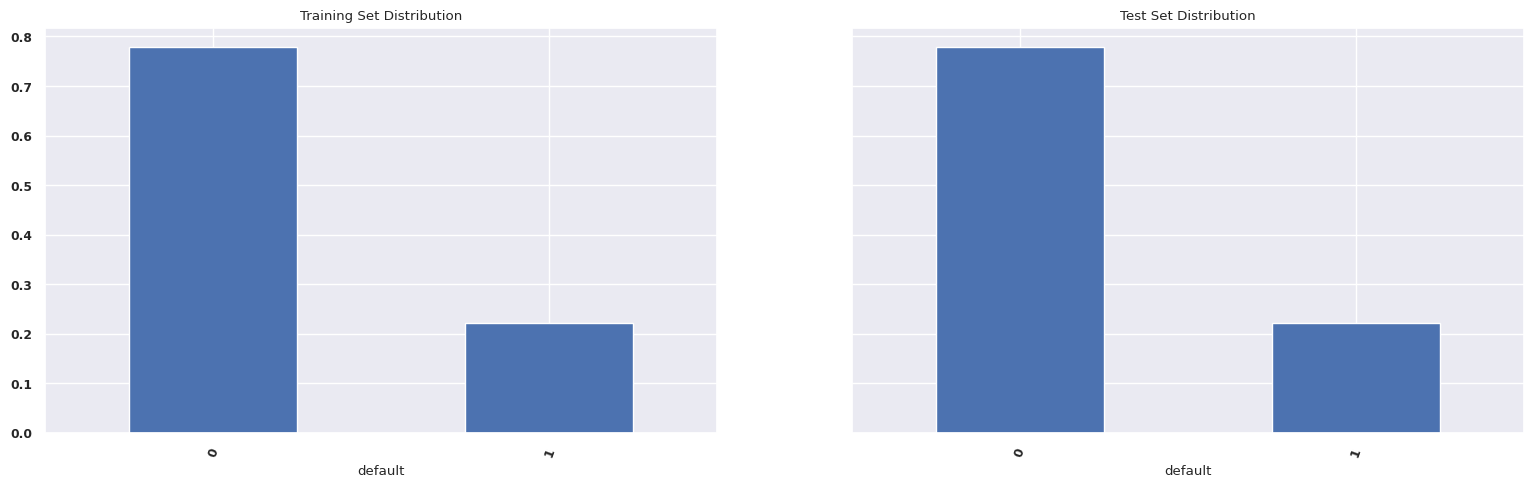

In [43]:
# compare the distribution of the two arrays
binary_balance(y_train, y_test)

In [44]:
# lazypredict
from lazypredict.Supervised import LazyClassifier

# load the lazyclassifier engine - specify settings
clf = LazyClassifier(verbose=0, ignore_warnings=True,
                     custom_metric=None, predictions=True)

# run the lazyclassifier engine
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

models

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 222
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.75,0.70,0.70,0.77,0.28
BernoulliNB,0.78,0.70,0.70,0.78,0.43
GaussianNB,0.81,0.66,0.66,0.79,0.24
LinearDiscriminantAnalysis,0.82,0.65,0.65,0.80,0.52
SVC,0.82,0.65,0.65,0.80,37.10
LogisticRegression,0.82,0.65,0.65,0.79,1.32
LGBMClassifier,0.82,0.65,0.65,0.79,0.53
RidgeClassifierCV,0.82,0.65,0.65,0.79,0.52
LinearSVC,0.82,0.65,0.65,0.79,0.38


In [45]:
# for better readability we can sort the results
models.sort_values(by=['Accuracy', 'F1 Score'], axis=0, ascending=False)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SVC,0.82,0.65,0.65,0.80,37.10
LGBMClassifier,0.82,0.65,0.65,0.79,0.53
CalibratedClassifierCV,0.82,0.65,0.65,0.79,1.53
LinearSVC,0.82,0.65,0.65,0.79,0.38
RidgeClassifier,0.82,0.65,0.65,0.79,0.26
RidgeClassifierCV,0.82,0.65,0.65,0.79,0.52
LinearDiscriminantAnalysis,0.82,0.65,0.65,0.80,0.52
LogisticRegression,0.82,0.65,0.65,0.79,1.32
SGDClassifier,0.82,0.64,0.64,0.79,0.54


In [46]:
# run a random forest classifier algorithm!
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

# step 1: initialise / load the model
classifier = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=4)

# step 2: train the model on X_train, y_train
classifier.fit(X_train, y_train)

# step 3: generate y_pred - using .predict()
y_pred = classifier.predict(X_test)

# step 4: evaluate the accuracy and compare y_pred to the true values y_test
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_accuracy)
print("F1-score: ", f1)

Accuracy: 0.8184444444444444
Balanced Accuracy: 0.6522214854847957
F1-score:  0.4632063074901445


Why are the results less than ideal? Potential Solutions?

1) Get more data: we haven't actually used all the features available in the dataset

2) Hyperparameter tuning and experimenting with different algorithms

3) Speak to domain experts to improve our feature engineering approach.
